In [2]:
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad

In [4]:
counts = pd.read_csv("./GSE144239/merge10pts_counts.txt", sep='\t')

In [5]:
counts

,P1_Tumor_AAACCTGAGTCAAGCG,P1_Tumor_AAACCTGCAAATTGCC,P1_Tumor_AAACCTGGTAGGAGTC,P1_Tumor_AAACGGGAGATGTAAC,P1_Tumor_AAACGGGAGCTGCAAG,P1_Tumor_AAAGATGAGAAGGTTT,P1_Tumor_AAAGATGCAATAACGA,P1_Tumor_AAAGATGCAGACTCGC,P1_Tumor_AAAGATGCAGTCAGCC,P1_Tumor_AAAGATGGTGGTGTAG,...,P10_Normal_TTTGGTTCACTCTGTC,P10_Normal_TTTGGTTCATCATCCC,P10_Normal_TTTGGTTCATCCCATC,P10_Normal_TTTGGTTTCTCTAAGG,P10_Normal_TTTGTCAAGACAATAC,P10_Normal_TTTGTCAAGAGTCTGG,P10_Normal_TTTGTCAAGTCGTTTG,P10_Normal_TTTGTCACAGTGGGAT,P10_Normal_TTTGTCATCCAGGGCT,P10_Normal_TTTGTCATCGAGGTAG
Patient,1,1,1,1,1,1,1,1,1,1,...,10,10,10,10,10,10,10,10,10,10
"Tissue: 0=Normal, 1=Tumor",1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
RP11-34P13.7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AL627309.1,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
AP006222.2,0,0,1,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AC145205.1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BAGE5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
CU459201.1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AC002321.2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
counts.to_pickle("./GSE144239/merge10pts_counts.pkl")

NameError: name 'counts' is not defined

In [4]:
import pickle

with open('./GSE144239/merge10pts_counts.pkl', 'rb') as file:
    data = pickle.load(file)

# 打印加载的数据
print(data)

                           P1_Tumor_AAACCTGAGTCAAGCG  \
Patient                                            1   
Tissue: 0=Normal, 1=Tumor                          1   
RP11-34P13.7                                       0   
AL627309.1                                         0   
AP006222.2                                         0   
...                                              ...   
AC145205.1                                         0   
BAGE5                                              0   
CU459201.1                                         0   
AC002321.2                                         0   
AC002321.1                                         0   

                           P1_Tumor_AAACCTGCAAATTGCC  \
Patient                                            1   
Tissue: 0=Normal, 1=Tumor                          1   
RP11-34P13.7                                       0   
AL627309.1                                         0   
AP006222.2                                     

In [5]:
data = data.T
print(data.head())

                           Patient  Tissue: 0=Normal, 1=Tumor  RP11-34P13.7  \
P1_Tumor_AAACCTGAGTCAAGCG        1                          1             0   
P1_Tumor_AAACCTGCAAATTGCC        1                          1             0   
P1_Tumor_AAACCTGGTAGGAGTC        1                          1             0   
P1_Tumor_AAACGGGAGATGTAAC        1                          1             0   
P1_Tumor_AAACGGGAGCTGCAAG        1                          1             0   

                           AL627309.1  AP006222.2  RP4-669L17.10  \
P1_Tumor_AAACCTGAGTCAAGCG           0           0              0   
P1_Tumor_AAACCTGCAAATTGCC           0           0              0   
P1_Tumor_AAACCTGGTAGGAGTC           0           1              0   
P1_Tumor_AAACGGGAGATGTAAC           0           0              0   
P1_Tumor_AAACGGGAGCTGCAAG           0           0              0   

                           RP11-206L10.3  RP11-206L10.2  RP11-206L10.9  \
P1_Tumor_AAACCTGAGTCAAGCG              0  

In [6]:
adata = sc.AnnData(X=data)

In [7]:
print(adata)
print(adata.var_names)
print(adata.obs_names)

AnnData object with n_obs × n_vars = 48164 × 32740
Index(['Patient', 'Tissue: 0=Normal, 1=Tumor', 'RP11-34P13.7', 'AL627309.1',
       'AP006222.2', 'RP4-669L17.10', 'RP11-206L10.3', 'RP11-206L10.2',
       'RP11-206L10.9', 'FAM87B',
       ...
       'BX072566.1', 'KIR2DL2', 'KIR3DL2.1', 'AL590523.1', 'CT476828.1',
       'AC145205.1', 'BAGE5', 'CU459201.1', 'AC002321.2', 'AC002321.1'],
      dtype='object', length=32740)
Index(['P1_Tumor_AAACCTGAGTCAAGCG', 'P1_Tumor_AAACCTGCAAATTGCC',
       'P1_Tumor_AAACCTGGTAGGAGTC', 'P1_Tumor_AAACGGGAGATGTAAC',
       'P1_Tumor_AAACGGGAGCTGCAAG', 'P1_Tumor_AAAGATGAGAAGGTTT',
       'P1_Tumor_AAAGATGCAATAACGA', 'P1_Tumor_AAAGATGCAGACTCGC',
       'P1_Tumor_AAAGATGCAGTCAGCC', 'P1_Tumor_AAAGATGGTGGTGTAG',
       ...
       'P10_Normal_TTTGGTTCACTCTGTC', 'P10_Normal_TTTGGTTCATCATCCC',
       'P10_Normal_TTTGGTTCATCCCATC', 'P10_Normal_TTTGGTTTCTCTAAGG',
       'P10_Normal_TTTGTCAAGACAATAC', 'P10_Normal_TTTGTCAAGAGTCTGG',
       'P10_Normal_TTTGTCAAGTC

In [8]:
meta = pd.read_csv("./GSE144239/patient_metadata_new.txt", sep="\t", index_col=0)

In [9]:
adata.obs = meta.loc[adata.obs_names]

In [10]:
print(adata.obs)

                             nCount_RNA  nFeature_RNA patient tum.norm  \
P1_Tumor_AAACCTGAGTCAAGCG         40856          5206      P1    Tumor   
P1_Tumor_AAACCTGCAAATTGCC         15511          3468      P1    Tumor   
P1_Tumor_AAACCTGGTAGGAGTC         24652          4154      P1    Tumor   
P1_Tumor_AAACGGGAGATGTAAC         27554          4334      P1    Tumor   
P1_Tumor_AAACGGGAGCTGCAAG         24980          4822      P1    Tumor   
...                                 ...           ...     ...      ...   
P10_Normal_TTTGTCAAGAGTCTGG        5585          1659     P10   Normal   
P10_Normal_TTTGTCAAGTCGTTTG       14207          3541     P10   Normal   
P10_Normal_TTTGTCACAGTGGGAT       10068          2540     P10   Normal   
P10_Normal_TTTGTCATCCAGGGCT        5223          1849     P10   Normal   
P10_Normal_TTTGTCATCGAGGTAG        3644          1598     P10   Normal   

                            level1_celltype  level2_celltype  level3_celltype  
P1_Tumor_AAACCTGAGTCAAGCG      

In [11]:
adata.write_h5ad("./GSE144239/scRNA-seq.h5ad")

In [12]:
filter_genes = pd.read_csv("protein_coding_hg38.txt", sep=",")

In [13]:
gene_list = filter_genes["Gene name"].dropna().tolist()

In [14]:
adata = adata[:, adata.var_names.isin(gene_list)].copy()

In [15]:
adata.write_h5ad("./GSE144239/scRNA-seq_filtered.h5ad")

In [16]:
adata = sc.read_h5ad("./GSE144239/scRNA-seq_filtered.h5ad")

In [17]:
obs_list_check = adata.obs_names.tolist()

In [18]:
keep_cells = adata.obs_names.str.startswith("P4_Tumor") | adata.obs_names.str.startswith("P6_Tumor")
adata_sub = adata[keep_cells].copy()

In [19]:
adata = adata_sub

In [20]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.leiden(adata, resolution=0.5)
sc.tl.umap(adata)

/home/mwc/miniconda3/envs/st/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_16594/1860111145.py:6: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.5)


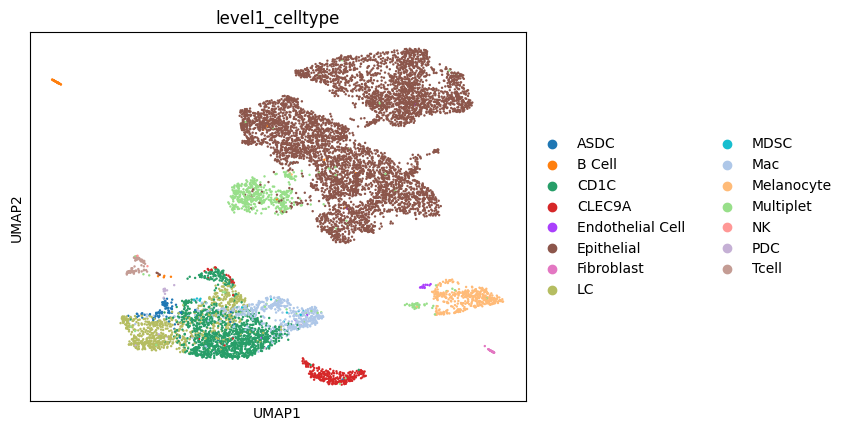

In [21]:
sc.pl.umap(adata, color='level1_celltype')

In [22]:
adata.write_h5ad("./GSE144239/P4_P6_Tumor.h5ad")